# **Classification**

In [1]:
# Import pandas library for data loading and manipulation
import pandas as pd
# Import numpy library for numerical operations
import numpy as np
# Import matplotlib for plotting graphs and visualizations
import matplotlib.pyplot as plt
# Import seaborn for better-looking statistical plots
import seaborn as sns
# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split
# Import StandardScaler to normalize/scale the feature values
from sklearn.preprocessing import StandardScaler
# Import LabelEncoder to convert text labels (pos/neg) into numbers (0/1)
from sklearn.preprocessing import LabelEncoder
# Import compute_class_weight to handle imbalanced dataset using class weights
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# Import Sequential model from Keras to build ANN layer by layer
from tensorflow.keras.models import Sequential
# Import Dense layer to add fully connected layers in the ANN
from tensorflow.keras.layers import Dense
# Import Dropout layer to prevent overfitting during ANN training
from tensorflow.keras.layers import Dropout
# Import classification report and confusion matrix to evaluate model performance
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Load the dataset from CSV file into a pandas dataframe
df = pd.read_csv('/content/01.1 aps_data.csv')

/tmp/ipykernel_2515/924475393.py:2: DtypeWarning: Columns (81) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/01.1 aps_data.csv')


In [4]:
df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,6,0,0,0,0,0,0,0,0,...,26,8,26,52,0,0,0,0,0,0
1,neg,90,0,0,66,0,0,0,0,0,...,1268,526,554,300,118,260,0,0,0,0
2,neg,30,na,16,14,0,0,0,0,0,...,480,84,74,50,46,0,0,0,0,0
3,neg,444,na,14,12,0,0,0,0,0,...,1614,1144,3598,2460,1258,8524,110,0,0,0
4,neg,82,na,12,10,0,0,0,0,1464,...,1010,132,310,56,92,1292,0,0,0,0


In [5]:
# Replace all string 'na' values with actual NaN (missing values) so pandas can handle them
df.replace('na', np.nan, inplace=True)

In [6]:
df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,6,0,0,0,0,0,0,0,0,...,26,8,26,52,0,0,0,0,0,0
1,neg,90,0,0,66,0,0,0,0,0,...,1268,526,554,300,118,260,0,0,0,0
2,neg,30,NaN,16,14,0,0,0,0,0,...,480,84,74,50,46,0,0,0,0,0
3,neg,444,NaN,14,12,0,0,0,0,0,...,1614,1144,3598,2460,1258,8524,110,0,0,0
4,neg,82,NaN,12,10,0,0,0,0,1464,...,1010,132,310,56,92,1292,0,0,0,0


In [7]:
# Check the shape of the dataset - rows and columns
print(df.shape)

(5000, 171)


In [8]:
# Check the class distribution to confirm data imbalance
print(df['class'].value_counts())

class
neg    4909
pos      91
Name: count, dtype: int64


In [9]:
# Check the percentage of missing values in each column
print(df.isnull().mean() * 100)

class      0.00
aa_000     0.00
ab_000    76.98
ac_000     6.16
ad_000    24.72
          ...  
ee_007     1.16
ee_008     1.16
ee_009     1.16
ef_000     4.84
eg_000     4.84
Length: 171, dtype: float64


In [10]:
# Drop columns where more than 50% of values are missing
df.dropna(thresh=len(df)*0.5, axis=1, inplace=True)

In [11]:
df.shape

(5000, 163)

In [12]:
# Separate the features (X) and the target column (y)
X = df.drop('class', axis=1)
y = df['class']

In [13]:
# Convert all feature columns to numeric, force any remaining text to NaN
X = X.apply(pd.to_numeric, errors='coerce')

In [14]:
# Fill any new NaN values created during conversion with median of each column
X.fillna(X.median(), inplace=True)

In [15]:
X.head()

,aa_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,614.0,...,26.0,8.0,26.0,52.0,0.0,0.0,0.0,0.0,0.0,0.0
1,90,0.0,66.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,...,1268.0,526.0,554.0,300.0,118.0,260.0,0.0,0.0,0.0,0.0
2,30,16.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0,...,480.0,84.0,74.0,50.0,46.0,0.0,0.0,0.0,0.0,0.0
3,444,14.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,17950.0,...,1614.0,1144.0,3598.0,2460.0,1258.0,8524.0,110.0,0.0,0.0,0.0
4,82,12.0,10.0,0.0,0.0,0.0,0.0,1464.0,4980.0,13632.0,...,1010.0,132.0,310.0,56.0,92.0,1292.0,0.0,0.0,0.0,0.0


In [16]:
# Encode target labels - convert 'neg' to 0 and 'pos' to 1
le = LabelEncoder()
y = le.fit_transform(y)

In [17]:
# Check the encoded class distribution
print(np.unique(y, return_counts=True))

(array([0, 1]), array([4909,   91]))


In [18]:
# Compute class weights to handle imbalance - higher weight given to minority class (pos)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)

In [19]:
# Convert class weights array into a dictionary format required by Keras
class_weight_dict = dict(enumerate(class_weights))

In [20]:
# Print the class weights to see how much importance each class gets
print(class_weight_dict)

{0: np.float64(0.5092686901609289), 1: np.float64(27.47252747252747)}


neg (0) → 4909 samples (majority)
pos (1) → 91 samples (minority)

What compute_class_weight does:
It uses this formula: weight = total_samples / (number_of_classes × samples_in_that_class)

Weight for class 0 (neg) = 5000 / (2 × 4909) = ≈ 0.51 → low weight because it has many samples

Weight for class 1 (pos) = 5000 / (2 × 91) = ≈ 27.47 → high weight because it has very few samples


What this means during training:

When the model makes a wrong prediction on a pos sample, the penalty (loss) is 27x higher than a wrong prediction on a neg sample.

This forces the model to pay more attention to the minority class (pos) instead of just predicting neg all the time.


Parameters explained:

class_weight='balanced' → automatically calculate weights using the formula above

classes=np.unique(y) → tells it your classes are [0, 1]

y=y → your actual target array to count samples per class

In [21]:
# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
# Check the shape of training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4000, 162)
X_test shape: (1000, 162)


In [23]:
# Create a StandardScaler object to scale features to same range
scaler = StandardScaler()

In [24]:
# Fit the scaler on training data and transform it
X_train = scaler.fit_transform(X_train)

# Transform test data using the same scaler fitted on training data
X_test = scaler.transform(X_test)

StandardScaler is the right choice for your dataset because it handles outliers much better than normalization.

In [25]:
# Create a Sequential model - this allows us to build ANN layer by layer
model = Sequential()

In [26]:
# Add first hidden layer with 64 neurons, relu activation and he_normal weight initialization for ReLU
model.add(Dense(64, activation='relu', kernel_initializer='he_normal', input_shape=(X_train.shape[1],)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
# Add dropout layer to randomly turn off 30% neurons to prevent overfitting
model.add(Dropout(0.3))

In [28]:
# Add second hidden layer with 32 neurons, relu activation and he_normal weight initialization
model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))

In [29]:
# Add dropout layer to randomly turn off 30% neurons to prevent overfitting
model.add(Dropout(0.3))

In [30]:
# Add output layer with 1 neuron and sigmoid activation for binary classification
model.add(Dense(1, activation='sigmoid'))

In [31]:
# Compile the model with adam optimizer, binary crossentropy loss for binary classification
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [32]:
# Print the model summary to see all layers, neurons and parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        10,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 0 (0.00 B)

Parameters = (inputs × neurons) + neurons (bias)

Layer 1 → dense (64 neurons)

Inputs = 162 features (your columns after dropping missing ones)
Parameters = (162 × 64) + 64
= 10,368 + 64
= 10,432

Layer 2 → dropout

Dropout just randomly turns off neurons
It has no learnable parameters
= 0


Layer 3 → dense_1 (32 neurons)

Inputs = 64 (output from previous dense layer)
Parameters = (64 × 32) + 32
= 2,048 + 32
= 2,080


Layer 4 → dropout_1

Again no learnable parameters
= 0


Layer 5 → dense_2 (1 neuron output layer)

Inputs = 32 (output from previous dense layer)
Parameters = (32 × 1) + 1
= 32 + 1
= 33


Why bias is added (+neurons)?

Every neuron has one extra bias value added to it
It helps the model shift the output and learn better
Think of it like the intercept in y = mx + c

Dropout does NOT drop all 64 neurons at once!
It drops 30% randomly → means only ~19 neurons are turned off each time, ~45 neurons are still active and passing information.


Epoch 1: neurons [1,5,9,12...19 neurons OFF] → 45 neurons pass info
Epoch 2: neurons [2,7,11,23...19 neurons OFF] → 45 neurons pass info
Epoch 3: neurons [3,8,15,31...19 neurons OFF] → 45 neurons pass info


Every epoch → different random neurons are turned off


Very Important:

Dropout only happens during training
During testing/prediction → Dropout is completely OFF
All 64 neurons are active during prediction


Why this helps?

Forces the network to not rely on any single neuron
Every neuron learns to work independently
Makes the model more generalized and less overfitted


Simple analogy:
Think of a cricket team of 11 players. During practice you randomly remove 3 players each day so every player learns all positions. During the actual match all 11 players play!

In [37]:
# Train the model with training data, class weights to handle imbalance, 50 epochs and batch size of 32
history = model.fit(X_train, y_train, epochs=50, batch_size=32, class_weight=class_weight_dict, validation_split=0.2, verbose=1)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8606 - loss: 0.5635 - val_accuracy: 0.9050 - val_loss: 0.2730
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9109 - loss: 0.1888 - val_accuracy: 0.9187 - val_loss: 0.2249
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9175 - loss: 0.3662 - val_accuracy: 0.9237 - val_loss: 0.2141
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9419 - loss: 0.1762 - val_accuracy: 0.9275 - val_loss: 0.1904
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9347 - loss: 0.1897 - val_accuracy: 0.9275 - val_loss: 0.2026
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9372 - loss: 0.1269 - val_accuracy: 0.9337 - val_loss: 0.1455
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9475 - loss: 0.1519 - val_accuracy: 0.9375 - val_loss: 0.1318
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9463 - loss: 0.1313 - val_accuracy: 0.

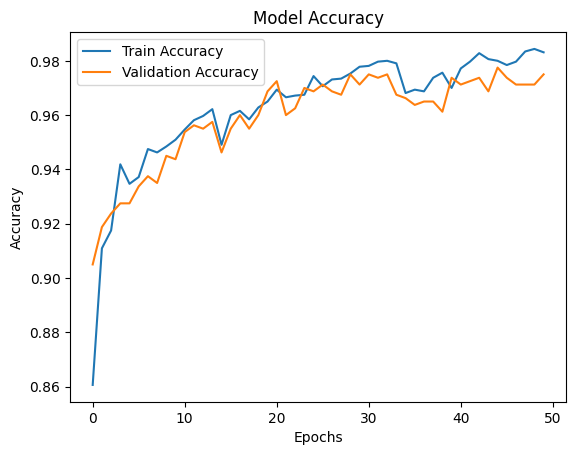

In [38]:
# Plot training and validation accuracy over all epochs to check model learning
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

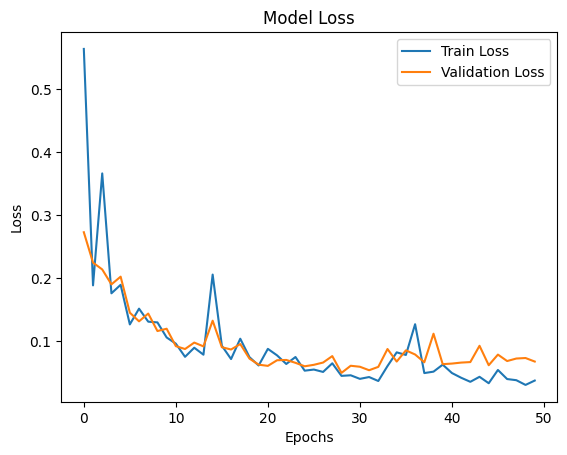

In [39]:
# Plot training and validation loss over all epochs to check if model is overfitting
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [40]:
# Predict probabilities on test data using the trained model
y_pred_prob = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [41]:
# Convert probabilities to class labels using 0.3 threshold (lower threshold to catch more positive cases)
y_pred = (y_pred_prob >= 0.3).astype(int)

In [43]:
# Print first 10 predictions vs actual values to verify
print("Predicted:", y_pred[:100].flatten())
print("Actual:   ", y_test[:100])

Predicted: [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
Actual:    [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [44]:
# Print detailed classification report showing precision, recall and f1-score for each class
print(classification_report(y_test, y_pred))

# Print confusion matrix to see true positives, true negatives, false positives and false negatives
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       982
           1       0.29      0.78      0.42        18

    accuracy                           0.96      1000
   macro avg       0.64      0.87      0.70      1000
weighted avg       0.98      0.96      0.97      1000

[[948  34]
 [  4  14]]


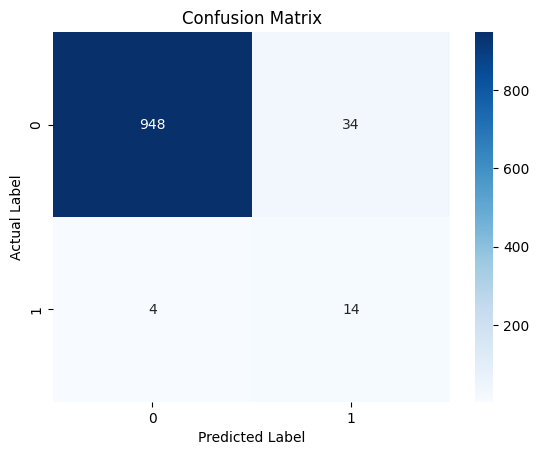

In [45]:
# Plot confusion matrix as a heatmap for better visualization
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [46]:
# Calculate and print the final test loss and test accuracy of the model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9710 - loss: 0.1121
Test Loss: 0.11213275790214539
Test Accuracy: 0.9710000157356262


In [47]:
# Install keras tuner library for hyperparameter tuning
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.4 MB/s eta 0:00:00


In [48]:
# Import keras tuner library for hyperparameter tuning
import keras_tuner as kt

In [49]:
# Define a function that builds ANN model with different hyperparameters for keras tuner to try
def build_model(hp):

    # Create a new sequential model
    model = Sequential()

    # Tune number of neurons in first hidden layer between 32 to 128 with step of 32
    model.add(Dense(units=hp.Int('units_layer1', min_value=32, max_value=128, step=32), activation='relu', kernel_initializer='he_normal', input_shape=(X_train.shape[1],)))

    # Tune dropout rate for first dropout layer between 0.2 to 0.5
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)))

    # Tune number of neurons in second hidden layer between 16 to 64 with step of 16
    model.add(Dense(units=hp.Int('units_layer2', min_value=16, max_value=64, step=16), activation='relu', kernel_initializer='he_normal'))

    # Tune dropout rate for second dropout layer between 0.2 to 0.5
    model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)))

    # Output layer with 1 neuron and sigmoid activation for binary classification
    model.add(Dense(1, activation='sigmoid'))

    # Tune learning rate for adam optimizer between 0.01 and 0.001
    model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', values=[0.01, 0.001])), loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [50]:
# Import tensorflow to use keras optimizers inside the tuner build function
import tensorflow as tf

In [51]:

# Create a RandomSearch tuner to find the best hyperparameters by trying different combinations
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=5, executions_per_trial=1, directory='tuner_results', project_name='ann_tuning')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
# Print the summary of search space to see what parameters will be tuned
tuner.search_space_summary()

Search space summary
Default search space size: 5
units_layer1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units_layer2 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
dropout_2 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001], 'ordered': True}


In [53]:
# Start the hyperparameter search using training data and class weights to handle imbalance
tuner.search(X_train, y_train, epochs=10, validation_split=0.2, class_weight=class_weight_dict, verbose=1)

Trial 5 Complete [00h 00m 08s]
val_accuracy: 0.9474999904632568

Best val_accuracy So Far: 0.9624999761581421
Total elapsed time: 00h 00m 37s


In [54]:
# Get the best hyperparameters found by the tuner after search is complete
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Print the best hyperparameters found by the tuner
print("Best neurons in layer 1:", best_hps.get('units_layer1'))
print("Best dropout rate 1:", best_hps.get('dropout_1'))
print("Best neurons in layer 2:", best_hps.get('units_layer2'))
print("Best dropout rate 2:", best_hps.get('dropout_2'))
print("Best learning rate:", best_hps.get('learning_rate'))

Best neurons in layer 1: 64
Best dropout rate 1: 0.2
Best neurons in layer 2: 48
Best dropout rate 2: 0.30000000000000004
Best learning rate: 0.001


In [55]:
# Build the best model using the best hyperparameters found by the tuner
best_model = tuner.hypermodel.build(best_hps)

In [56]:
# Train the best model with full training data and class weights for 50 epochs
history_tuned = best_model.fit(X_train, y_train, epochs=50, batch_size=32, class_weight=class_weight_dict, validation_split=0.2, verbose=1)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8637 - loss: 1.1671 - val_accuracy: 0.8687 - val_loss: 0.4919
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8931 - loss: 0.4452 - val_accuracy: 0.9013 - val_loss: 0.4335
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9253 - loss: 0.2180 - val_accuracy: 0.9362 - val_loss: 0.2410
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9438 - loss: 0.1609 - val_accuracy: 0.9488 - val_loss: 0.1794
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9456 - loss: 0.2872 - val_accuracy: 0.9488 - val_loss: 0.2004
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9475 - loss: 0.1738 - val_accuracy: 0.9438 - val_loss: 0.1796
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9478 - loss: 0.1526 - val_accuracy: 0.9463 - val_loss: 0.1657
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9450 - loss: 0.2150 - val_accuracy: 0.

In [57]:
# Predict probabilities on test data using the best tuned model
y_pred_tuned_prob = best_model.predict(X_test)

# Convert probabilities to class labels using 0.3 threshold
y_pred_tuned = (y_pred_tuned_prob >= 0.3).astype(int)

# Print classification report to compare tuned model performance with original model
print(classification_report(y_test, y_pred_tuned))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       982
           1       0.29      0.83      0.43        18

    accuracy                           0.96      1000
   macro avg       0.65      0.90      0.71      1000
weighted avg       0.98      0.96      0.97      1000



In [58]:
# Save the trained model to disk in keras format for future use
model.save('ann_aps_model.keras')

# Print confirmation message that model is saved successfully
print("Model saved successfully!")

Model saved successfully!


In [59]:
# Load the saved model back from disk
from tensorflow.keras.models import load_model
loaded_model = load_model('ann_aps_model.keras')

# Print confirmation message that model is loaded successfully
print("Model loaded successfully!")

Model loaded successfully!


In [60]:
# Take one random unseen sample from test data to simulate new unseen data
new_data = X_test[0].reshape(1, -1)

# Predict probability of the new sample using the loaded model
new_pred_prob = loaded_model.predict(new_data)

# Convert probability to class label using 0.3 threshold
new_pred_class = (new_pred_prob >= 0.3).astype(int)

print("Predicted Probability:", new_pred_prob[0][0])
print("Predicted Class:", "APS Failure (pos)" if new_pred_class[0][0] == 1 else "No Failure (neg)")
print("Actual Class:", "APS Failure (pos)" if y_test[0] == 1 else "No Failure (neg)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
Predicted Probability: 0.0002592494
Predicted Class: No Failure (neg)
Actual Class: No Failure (neg)


# **Regression**

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5

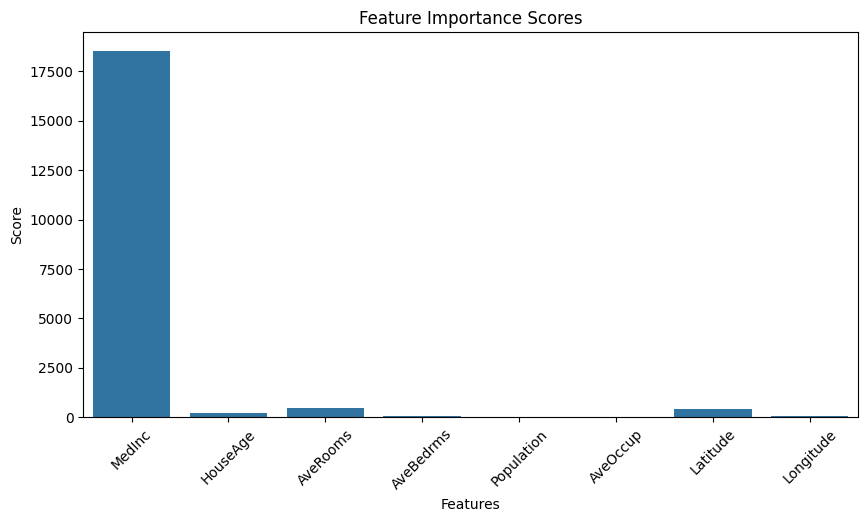

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - loss: 2.1983 - mae: 1.1132 - val_loss: 0.6282 - val_mae: 0.5841
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0266 - mae: 0.7705 - val_loss: 0.5869 - val_mae: 0.5551
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8591 - mae: 0.6959 - val_loss: 0.5628 - val_mae: 0.5239
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7774 - mae: 0.6558 - val_loss: 0.5502 - val_mae: 0.5188
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7175 - mae: 0.6273 - val_loss: 0.5349 - val_mae: 0.5100
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6872 - mae: 0.6132 - val_loss: 0.5558 - val_mae: 0.5169
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6698 - mae: 0.6034 - val_loss: 0.5168 - val_mae: 0.5057
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6407 - mae: 0.5871 - val_loss: 0.5533 - val_mae: 0.5152
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3m

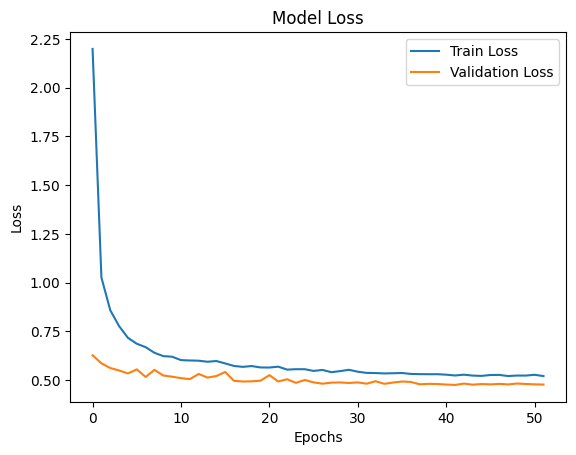

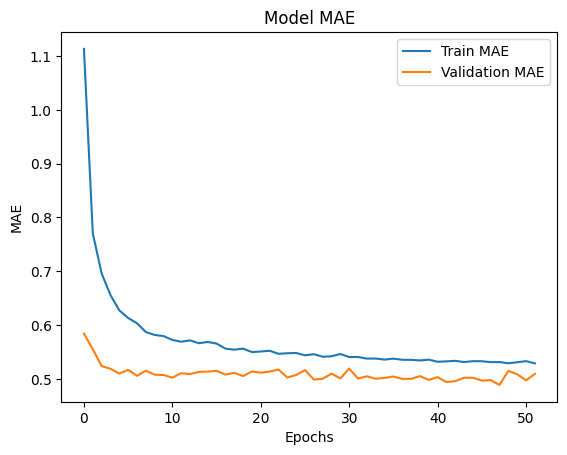

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error (MSE): 0.4907462693490467
Root Mean Squared Error (RMSE): 0.7005328467310057
Mean Absolute Error (MAE): 0.49847144817243716
R2 Score: 0.6255014445888281


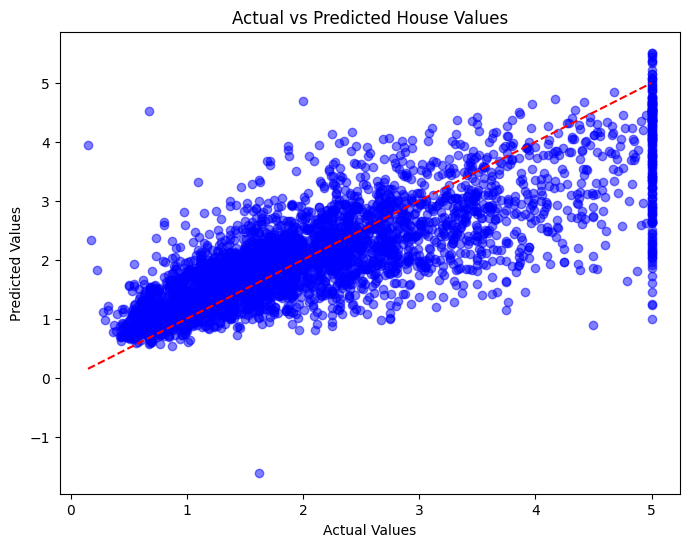

Model saved successfully!


In [ ]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Load california housing dataset
data = fetch_california_housing()

# Convert to dataframe
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column to dataframe
df['MedHouseVal'] = data.target

# Check shape and first 5 rows
print(df.shape)
print(df.head())

# Check missing values
print(df.isnull().sum())

# Check basic statistics
print(df.describe())

# Separate features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Apply SelectKBest with f_regression to select top 5 most important features
selector = SelectKBest(score_func=f_regression, k=5)

# Fit selector on data and transform
X_selected = selector.fit_transform(X, y)

# Get selected feature names
selected_feature_names = X.columns[selector.get_support()].tolist()
print("Selected Features:", selected_feature_names)

# Plot feature scores to visualize importance of each feature
plt.figure(figsize=(10, 5))
sns.barplot(x=X.columns, y=selector.scores_)
plt.title('Feature Importance Scores')
plt.xlabel('Features')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.show()

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Scale features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build ANN model for regression
model = Sequential()

# First hidden layer with 128 neurons and relu activation
model.add(Dense(128, activation='relu', kernel_initializer='he_normal', input_shape=(X_train.shape[1],)))

# Batch normalization to stabilize training
model.add(BatchNormalization())

# Dropout to prevent overfitting
model.add(Dropout(0.3))

# Second hidden layer with 64 neurons
model.add(Dense(64, activation='relu', kernel_initializer='he_normal'))

# Batch normalization
model.add(BatchNormalization())

# Dropout
model.add(Dropout(0.3))

# Third hidden layer with 32 neurons
model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))

# Dropout
model.add(Dropout(0.2))

# Output layer with 1 neuron and no activation function for regression
model.add(Dense(1))

# Compile model with adam optimizer and mean squared error loss for regression
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Print model summary
model.summary()

# Define early stopping to stop training when val_loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)

# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation MAE
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

# Predict on test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics for regression
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print all evaluation metrics
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R2 Score:", r2)

# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted House Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

# Save the model
model.save('ann_regression_model.keras')
print("Model saved successfully!")